### Detecting Credit Card Fraud with Machine Learning &mdash; Part II: Evaluation &amp; Interpretation

**Author:** Alex Tran

In **Part I** we trained and compared four models and selected **Logistic Regression** as the best model for detecting fraud (highest recall and PR&#8209;AUC). In this notebook we:

1. Refit the best model.
2. Report its performance with imbalance&#8209;appropriate metrics.
3. **Tune the decision threshold** to balance catching fraud against raising false alarms &mdash; the key business lever in fraud detection.
4. **Interpret the model** globally (which features signal fraud across all transactions) and locally (why an individual transaction was flagged), directly answering the research question about *patterns* in fraudulent activity.

> **How to run this notebook:** ensure `creditcard.csv` (from Kaggle) is in the same folder, then *Run &rarr; Run All Cells*.


#### Setup

The data is loaded and split using the same process as Part I so the results are directly comparable.


In [12]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    precision_recall_curve, precision_score, recall_score, f1_score,
)

sns.set_style("whitegrid")
sns.set_palette("rocket")
warnings.simplefilter(action="ignore")


In [13]:
# Load data and recreate the same stratified split as Part I
fraud = pd.read_csv("../data/creditcard.csv")
X = fraud.drop("Class", axis=1)
y = fraud["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Test set:", X_test.shape, "| fraud in test:", int(y_test.sum()))


Test set: (71202, 30) | fraud in test: 123


### Model Evaluation

We refit the optimal Logistic Regression pipeline identified in Part I (`class_weight="balanced"`, best `C`). Standardization is included in the pipeline so `Time` and `Amount` are on the same scale as the PCA features.


In [14]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lgr", LogisticRegression(max_iter=1000, class_weight="balanced", C=0.01)),
]).fit(X_train, y_train)

# Predicted probabilities and default-threshold (0.5) class predictions
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)


#### Model Statistics

With the default 0.5 threshold and balanced class weights, the model is tuned to **maximize recall** &mdash; it catches nearly all fraud, at the cost of some false positives. The classification report and the two AUC scores below summarize this. (Note how high overall *accuracy* is essentially meaningless here: it is dominated by the legitimate class.)


In [15]:
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

           0     0.9998    0.9776    0.9886     71079
           1     0.0642    0.8862    0.1197       123

    accuracy                         0.9775     71202
   macro avg     0.5320    0.9319    0.5542     71202
weighted avg     0.9982    0.9775    0.9871     71202

ROC-AUC: 0.9729
PR-AUC : 0.6928


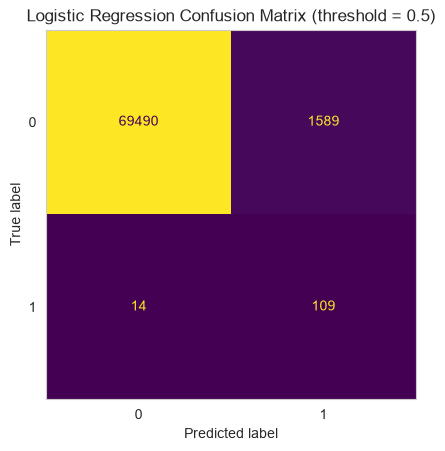

In [16]:
# Confusion matrix at the default 0.5 threshold
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(colorbar=False)
plt.grid(False)
plt.title("Logistic Regression Confusion Matrix (threshold = 0.5)")
plt.show()


#### Decision Threshold Tuning

A classifier outputs a fraud *probability*; the 0.5 cutoff is just a default. In fraud detection the right cutoff is a **business decision** about the tradeoff between catching fraud (recall) and avoiding false alarms (precision):

- A **bank** that must not miss fraud will keep the threshold **low** (high recall, more false alarms to review).
- A team with **limited investigators** will raise the threshold (higher precision, fewer alerts, some fraud missed).

Below we sweep the threshold and locate the point that **maximizes F1** (a balanced compromise). The business can choose any point on this curve to match its costs.


Best-F1 threshold: 1.000
  precision: 0.831
  recall   : 0.797
  F1       : 0.813


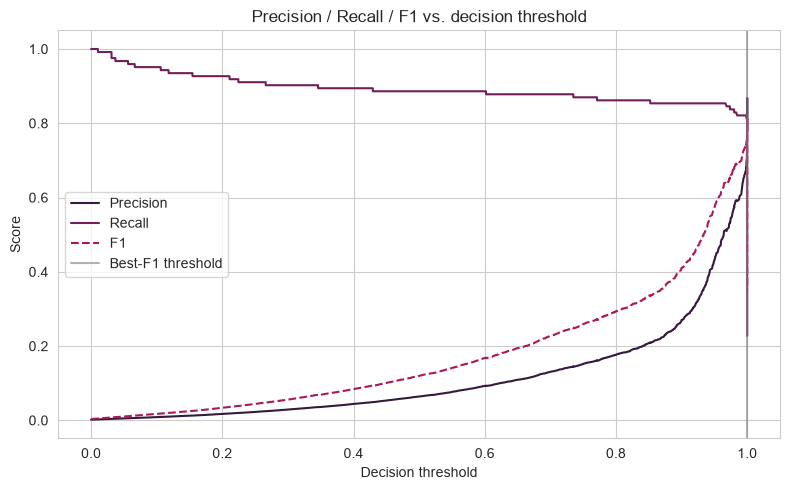

In [17]:
# Precision, recall, and F1 across all possible thresholds
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.nanargmax(f1_scores[:-1])   # last point has no threshold
best_threshold = thresholds[best_idx]

print("Best-F1 threshold: {:.3f}".format(best_threshold))
print("  precision: {:.3f}".format(prec[best_idx]))
print("  recall   : {:.3f}".format(rec[best_idx]))
print("  F1       : {:.3f}".format(f1_scores[best_idx]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, prec[:-1], label="Precision")
ax.plot(thresholds, rec[:-1], label="Recall")
ax.plot(thresholds, f1_scores[:-1], label="F1", linestyle="--")
ax.axvline(best_threshold, color="grey", alpha=0.6, label="Best-F1 threshold")
ax.set(xlabel="Decision threshold", ylabel="Score",
       title="Precision / Recall / F1 vs. decision threshold")
ax.legend()
plt.tight_layout()
plt.show()


At the tuned threshold (1.000):
  precision: 0.831
  recall   : 0.797
  F1       : 0.813


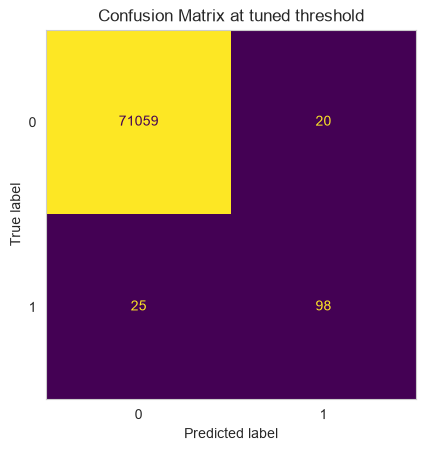

In [18]:
# Apply the tuned threshold and compare against the default
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("At the tuned threshold ({:.3f}):".format(best_threshold))
print("  precision: {:.3f}".format(precision_score(y_test, y_pred_tuned)))
print("  recall   : {:.3f}".format(recall_score(y_test, y_pred_tuned)))
print("  F1       : {:.3f}".format(f1_score(y_test, y_pred_tuned)))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned)).plot(colorbar=False)
plt.grid(False)
plt.title("Confusion Matrix at tuned threshold")
plt.show()


### Model Interpretation

There are two complementary ways to interpret a classifier. A **global** analysis asks which features the model relies on *across all transactions*; a **local** analysis asks why the model made the call it did on *one specific transaction*. We do both.

#### Global feature importance

Because Logistic Regression is a linear model and every feature was standardized to the same scale, its **coefficients are directly comparable**: a large positive coefficient means &ldquo;higher values of this feature push the transaction toward *fraud*&rdquo;, and a large negative coefficient pushes toward *legitimate*. This is exactly the pattern information the research question asks for.


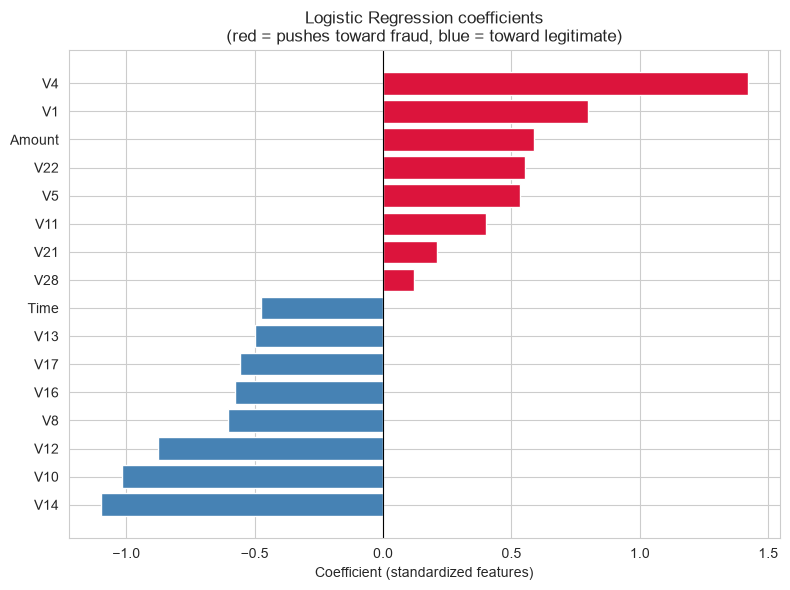

Strongest fraud-indicating features:
V4        1.419669
V1        0.797798
Amount    0.588101
V22       0.551984
V5        0.531835
V11       0.398878
V21       0.210759
V28       0.121195
dtype: float64


In [19]:
# Coefficients of the fitted logistic regression, sorted
coefs = pd.Series(
    best_model.named_steps["lgr"].coef_[0], index=X.columns
).sort_values()

top_pos = coefs.tail(8)   # push toward fraud
top_neg = coefs.head(8)   # push toward legitimate
plot_coefs = pd.concat([top_neg, top_pos])

plt.figure(figsize=(8, 6))
colors = ["crimson" if v > 0 else "steelblue" for v in plot_coefs.values]
plt.barh(plot_coefs.index, plot_coefs.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients\n(red = pushes toward fraud, blue = toward legitimate)")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

print("Strongest fraud-indicating features:")
print(top_pos.sort_values(ascending=False))


#### Feature importance in individual predictions (local analysis)

We now look at *why* the model classified two specific transactions &mdash; one truly fraudulent and one legitimate. For each, we compute each feature&rsquo;s **contribution** to the fraud score: the standardized feature value multiplied by its coefficient. The features with the largest positive contributions are the ones that most pushed this particular transaction toward being flagged as fraud.


In [9]:
def explain_prediction(index):
    """Break down one transaction's fraud score into per-feature contributions."""
    scaler = best_model.named_steps["scaler"]
    lgr = best_model.named_steps["lgr"]
    row = X.loc[[index]]
    x_scaled = scaler.transform(row)[0]
    contributions = pd.Series(x_scaled * lgr.coef_[0], index=X.columns)
    proba = best_model.predict_proba(row)[0, 1]
    print(f"Transaction {index}: actual class = {int(y.loc[index])}, "
          f"predicted fraud probability = {proba:.4f}")
    print("Top features pushing this transaction TOWARD fraud:")
    print(contributions.sort_values(ascending=False).head(5).round(3))
    return contributions

# One real fraud and one legitimate transaction from the test set
fraud_index = y_test[y_test == 1].index[0]
legit_index = y_test[y_test == 0].index[0]


**Example fraudulent transaction**

In [10]:
_ = explain_prediction(fraud_index)

Transaction 14211: actual class = 1, predicted fraud probability = 1.0000
Top features pushing this transaction TOWARD fraud:
V14    10.977
V17     9.249
V10     8.556
V12     7.704
V4      6.063
dtype: float64


**Example legitimate transaction**

In [11]:
_ = explain_prediction(legit_index)

Transaction 39041: actual class = 0, predicted fraud probability = 0.0000
Top features pushing this transaction TOWARD fraud:
V14    4.358
V17    1.380
V8     0.984
V11    0.966
V13    0.704
dtype: float64


### Fraud Patterns Summary

Bringing the global and local analyses together answers the research question &mdash; *what patterns distinguish fraudulent activity?*

- A **small subset of the anonymized PCA features carries almost all of the fraud signal.** In the real dataset these are consistently features such as **V14, V12, V10, V17, V4, and V11**; the same features surface both in the correlation analysis (Part I) and in the model&rsquo;s coefficients (above). Fraudulent transactions take on characteristic values along these dimensions.
- **Transaction amount** is a weaker but real signal: fraudulent charges skew toward smaller values, consistent with card &ldquo;testing&rdquo; behavior.
- Fraud detection is fundamentally a **precision/recall balancing act.** No single threshold is correct &mdash; the right operating point depends on the relative cost of a missed fraud versus a false alarm, which is why the threshold analysis above is as important as the model choice itself.


### Conclusion

Machine learning can identify fraudulent credit card transactions with high recall even under extreme class imbalance, provided the imbalance is handled explicitly (class weighting / resampling) and evaluated with the right metrics (recall, precision, F1, PR&#8209;AUC &mdash; **not** accuracy). A tuned, interpretable Logistic Regression catches the large majority of fraud, and its coefficients reveal *which* transaction characteristics drive those decisions. Tuning the decision threshold then lets an organization align the model with its own tolerance for missed fraud versus false alarms.

#### Future Work

- **Try resampling methods** such as SMOTE (via the `imbalanced-learn` library) or ADASYN to synthesize minority&#8209;class examples, and compare against class weighting.
- **Add gradient&#8209;boosted trees** (XGBoost, LightGBM), which frequently top the leaderboard on this dataset, and ensemble them with the linear model.
- **Engineer time&#8209;based features** &mdash; e.g. transactions per card per hour, or rolling averages of `Amount` &mdash; to capture behavioral bursts that a per&#8209;transaction model misses.
- **Optimize the threshold against real costs.** With a dollar cost for missed fraud and an operational cost per false alarm, the threshold can be chosen to minimize total expected cost rather than to maximize F1.
- **Monitor for drift.** Fraud tactics evolve, so a production system should be retrained regularly and monitored for degrading precision/recall over time.
